<a href="https://colab.research.google.com/github/0xPranjl/Enchancedpytorchmodels/blob/models/irismodel_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

In [20]:
class Ann(nn.Module):
  def __init__(self,features):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Linear(4,8),
        nn.ReLU(),
        nn.Linear(8,6),
        nn.ReLU(),
        nn.Linear(6,3)
    )
  def forward(self,x):
    return self.layers(x)

In [21]:
#pick  a manual seed for deterministic
torch.manual_seed(41)

In [22]:
import numpy as np
from sklearn.datasets import load_iris

In [23]:
iris=load_iris()
X=iris.data
Y=iris.target


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

In [26]:
#convert dataset to tensors
X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)
y_train=torch.LongTensor(y_train)
y_test=torch.LongTensor(y_test)


In [27]:
ann=Ann(4)

In [28]:
#losss and optimization
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(ann.parameters(),lr=0.01)


In [29]:
#training and epoches
epoches=100
losses=[]
for i in range(epoches):
  y_pred=ann(X_train)
  loss=criterion(y_pred,y_train)
  losses.append(loss)
  if i%10==0:
    print(f'epoch:{i} loss:{loss}')
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

epoch:0 loss:1.2663875818252563
epoch:10 loss:1.056169867515564
epoch:20 loss:0.8952279686927795
epoch:30 loss:0.6419433951377869
epoch:40 loss:0.42042461037635803
epoch:50 loss:0.2743458151817322
epoch:60 loss:0.17408880591392517
epoch:70 loss:0.11680638790130615
epoch:80 loss:0.08774115145206451
epoch:90 loss:0.0721781775355339


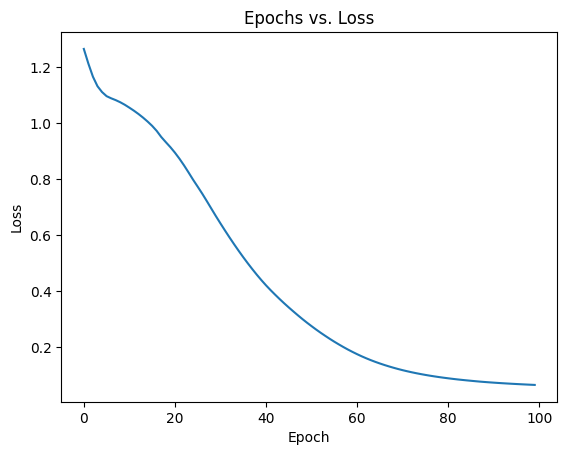

In [30]:
#plotting epoches vs losses (optional)
import matplotlib.pyplot as plt

plt.plot(range(epoches), [l.item() for l in losses])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Epochs vs. Loss')
plt.show()

In [31]:
with torch.no_grad():
  y_eval=ann(X_test)
  loss=criterion(y_eval,y_test)
  print(f'loss:{loss}')

loss:0.0803515836596489


In [42]:
correct=0
with torch.no_grad():
  for i,data in enumerate(X_test):
    y_eval=ann(data)
    if y_eval.argmax().item()==y_test[i]:
      correct=correct+1
  print(f'accuracy:{correct/len(y_test)}')



accuracy:0.9666666666666667


In [44]:
#testing our own data
with torch.no_grad():
  testo=torch.tensor([5.9,2.5,3.2,1.7])
  res=ann(testo)
  print(res.argmax().item())

1


In [45]:
#saving our nn model
torch.save(ann.state_dict(),'iris_model.pt')

In [47]:
#loading our model
new_model=Ann(4)
new_model.load_state_dict(torch.load('iris_model.pt'))

<All keys matched successfully>

In [49]:
#testing model if its working correctly
with torch.no_grad():
  test1=torch.tensor([5.2,2.7,3.8,1.9])
  yo=new_model(test1)